In [1]:
# Enable automatic reloading of modules before executing code
%load_ext autoreload
%autoreload 2

In [2]:
import os
import copy

from functools import partial, reduce

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import pingouin as pg
from PIL import Image

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

import matplotlib.colors as mcolors

In [3]:
import utils as ut

In [4]:
pd.set_option('display.max_columns', 100)

In [5]:
# test run of the model for dev purposes, or full/final data set?


is_testcase = False

# Load Model Results from Disk

In [6]:
# free weights free scaling models

l_data_subset = ["full_evaluate_actual", "full_evaluate_shuffled"]
l_rnd_seed = [1]
l_embed_dim = [200]
l_lmbda = [0.0000001, 0.0005, 0.008, 0.05, 0.1, 0.5, 0.9]
modeltype = "free_weights_free_scaling"
modelversion = "embeddings-decision-combined-data"

l_load = ut.load_ID_lowdim_id_weights(
    l_data_subset=l_data_subset, l_rnd_seed=l_rnd_seed, l_lmbda=l_lmbda,
    l_embed_dim=l_embed_dim, modelversion=modelversion, modeltype=modeltype
)
l_results_fwfs = l_load[0]


# free weights no scaling models

modeltype = "free_weights_no_scaling"

l_load = ut.load_ID_lowdim_id_weights(
    l_data_subset=l_data_subset, l_rnd_seed=l_rnd_seed, l_lmbda=l_lmbda,
    l_embed_dim=l_embed_dim, modelversion=modelversion, modeltype=modeltype
)
l_results_fwns = l_load[0]


In [7]:
def make_result_df(l):
    my_df = pd.DataFrame()
    my_df["test_accs_proba"] = l["test_accs_proba"]
    my_df["test_accs_max"] = l["test_accs_max"]
    my_df["modeltype"] = np.repeat(l["modeltype"], len(l["test_accs_proba"]))
    my_df["n_embed"] = np.repeat(l["n_embed"], len(l["test_accs_proba"]))
    my_df["lmbda"] = np.repeat(l["lmbda"], len(l["test_accs_proba"]))
    my_df["data_subset"] = np.repeat(l["data_subset"], len(l["test_accs_proba"]))
    my_df['tmp'] = l["nneg_d_over_time"]
    my_df["nneg_d_over_time"] = my_df["tmp"].astype(str).str.extract(r"\(\d+,\s*(\d+)\)")
    my_df['epoch'] = my_df["tmp"].astype(str).str.extract(r"\((\d+)")
    my_df.drop(columns=["tmp"], inplace=True)
    
    return my_df

In [8]:
l_result_dfs_fwfs = list(map(make_result_df, l_results_fwfs))
l_result_dfs_fwns = list(map(make_result_df, l_results_fwns))

In [9]:
tbl_result_df_fwfs = reduce(lambda x, y: pd.concat([x, y], axis=0), l_result_dfs_fwfs)
tbl_result_df_fwns = reduce(lambda x, y: pd.concat([x, y], axis=0), l_result_dfs_fwns)
tbl_result_df = pd.concat([tbl_result_df_fwfs, tbl_result_df_fwns], axis=0)

In [11]:
tbl_plot_results = tbl_result_df.groupby(["modeltype", "n_embed", "lmbda", "data_subset", "nneg_d_over_time"]).agg("max").reset_index()
tbl_plot_results["row_number"] = (
    tbl_plot_results
    .groupby(["modeltype", "n_embed", "lmbda", "data_subset"])
    ["test_accs_max"]
    .rank(method="first", ascending=False)
    .astype(int)
)
tbl_plot_results = tbl_plot_results.query("row_number == 1")
tbl_plot_results.drop(columns=["row_number", "epoch"], inplace=True)

In [14]:
tbl_plot_results.sort_values("test_accs_proba", ascending=False).head()

,modeltype,n_embed,lmbda,data_subset,nneg_d_over_time,test_accs_proba,test_accs_max
36,free_weights_no_scaling,200,5.000000e-04,full_evaluate_actual,200,0.584398,0.658793
34,free_weights_no_scaling,200,1.000000e-07,full_evaluate_actual,200,0.584064,0.659169
39,free_weights_no_scaling,200,8.000000e-03,full_evaluate_actual,85,0.580955,0.662650
0,free_weights_free_scaling,200,1.000000e-07,full_evaluate_actual,200,0.579764,0.651322
2,free_weights_free_scaling,200,5.000000e-04,full_evaluate_actual,200,0.579614,0.652024


C:\Users\MirkoThalmann\miniconda3\envs\representationsID1\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\MirkoThalmann\miniconda3\envs\representationsID1\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\MirkoThalmann\miniconda3\envs\representationsID1\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\MirkoThalmann\miniconda3\envs\representationsID1\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Setting a gradi

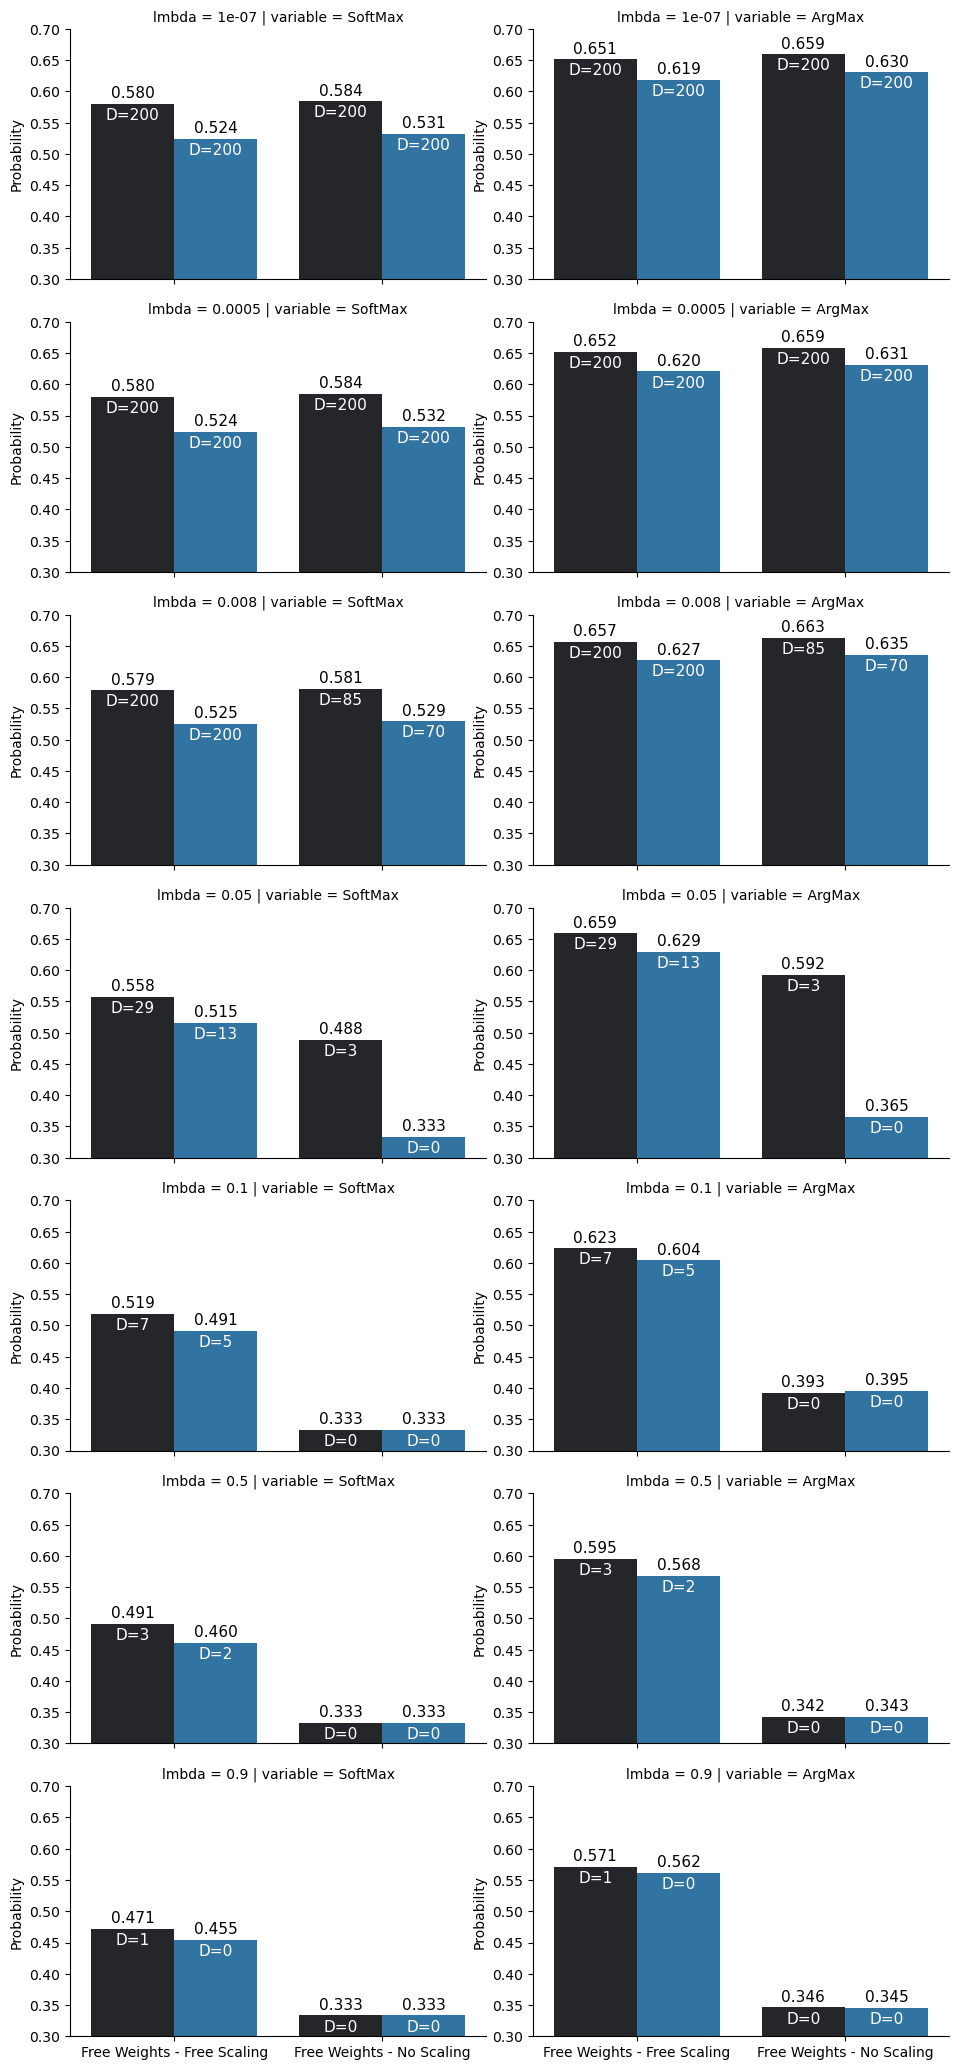

In [46]:
tbl_plot_long = tbl_plot_results.melt(id_vars=["modeltype", "n_embed", "lmbda", "data_subset", "nneg_d_over_time"])
tbl_plot_long.loc[tbl_plot_long["modeltype"] == "free_weights_free_scaling", "modeltype"] = "Free Weights - Free Scaling"
tbl_plot_long.loc[tbl_plot_long["modeltype"] == "free_weights_no_scaling", "modeltype"] = "Free Weights - No Scaling"
tbl_plot_long.loc[tbl_plot_long["data_subset"] == "full_evaluate_actual", "data_subset"] = "Actual"
tbl_plot_long.loc[tbl_plot_long["data_subset"] == "full_evaluate_shuffled", "data_subset"] = "Shuffled"
tbl_plot_long.loc[tbl_plot_long["variable"] == "test_accs_proba", "variable"] = "SoftMax"
tbl_plot_long.loc[tbl_plot_long["variable"] == "test_accs_max", "variable"] = "ArgMax"

g = sns.FacetGrid(data=tbl_plot_long, col="variable", row="lmbda", aspect=1.6, sharey=False)
g.map_dataframe(sns.barplot, x="modeltype", y="value", hue="data_subset")

# Add text to each facet
def add_text(data, **kwargs):
    ax = plt.gca()
    # Get the unique hue levels and their order
    hue_order = sorted(data["data_subset"].unique())
    n_hue = len(hue_order)
    
    # Get the width of each bar group
    bar_width = 0.8 / n_hue  # Seaborn default total width is ~0.8

    # Map each hue level to an offset
    hue_offsets = {hue: i * bar_width - 0.4 + bar_width / 2 for i, hue in enumerate(hue_order)}

    for i, row in data.iterrows():
        # Get base x position (as categorical index)
        x_base = list(data["modeltype"].unique()).index(row["modeltype"])
        x = x_base + hue_offsets[row["data_subset"]]
        ax.text(x, row["value"] + 0.01, f"{row['value']:.3f}", ha="center", fontsize=11)
        ax.text(x, row["value"] - 0.025, f"D={row['nneg_d_over_time']}", ha="center", fontsize=11, color="white")

g.map_dataframe(add_text)

for ax in g.axes.flatten():
    ax.set_ylim((.3, .7))
    ax.set_xlabel("")
    ax.set_ylabel("Probability")
    
#_ = plt.tight_layout()


In [18]:
tbl_plot_long.head()

,modeltype,n_embed,lmbda,data_subset,nneg_d_over_time,variable,value
0,Free Weights - Free Scaling,200,1.000000e-07,Actual,200,SoftMax,0.579764
1,Free Weights - Free Scaling,200,1.000000e-07,Shuffled,200,SoftMax,0.523673
2,Free Weights - Free Scaling,200,5.000000e-04,Actual,200,SoftMax,0.579614
3,Free Weights - Free Scaling,200,5.000000e-04,Shuffled,200,SoftMax,0.524049
4,Free Weights - Free Scaling,200,8.000000e-03,Actual,200,SoftMax,0.578949


In [26]:
tbl_plot_long.head()

,Model,n_embed,lmbda,Subject IDs,nneg_d_over_time,variable,value,lmbda_cat
0,Free Weights - Free Scaling,200,1.000000e-07,Actual,200,SoftMax,0.579764,1e-07
1,Free Weights - Free Scaling,200,1.000000e-07,Shuffled,200,SoftMax,0.523673,1e-07
2,Free Weights - Free Scaling,200,5.000000e-04,Actual,200,SoftMax,0.579614,0.0005
3,Free Weights - Free Scaling,200,5.000000e-04,Shuffled,200,SoftMax,0.524049,0.0005
4,Free Weights - Free Scaling,200,8.000000e-03,Actual,200,SoftMax,0.578949,0.008


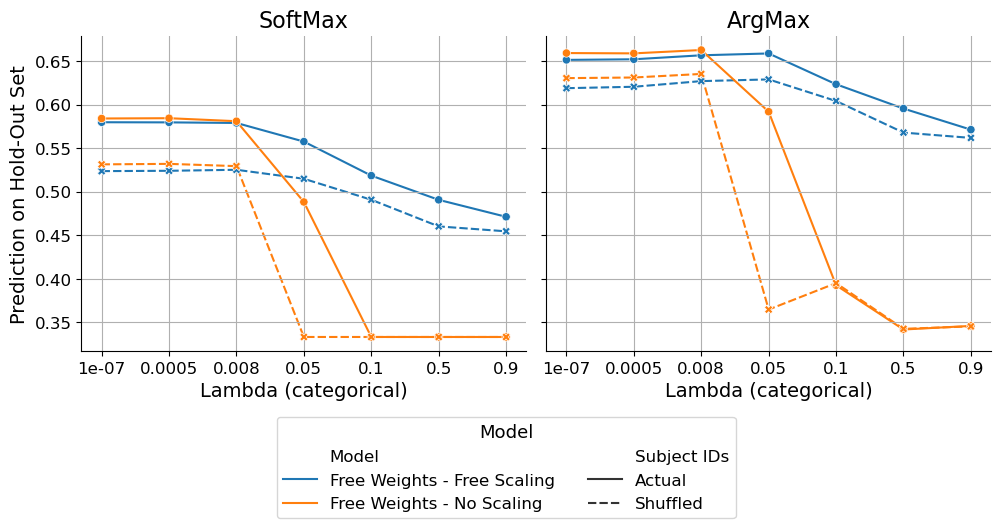

In [65]:
ordered_lmbda = sorted(tbl_plot_long["lmbda"].unique())
tbl_plot_long["lmbda_cat"] = pd.Categorical(
    tbl_plot_long["lmbda"].astype(str),
    categories=[f"{x}" for x in ordered_lmbda],
    ordered=True
)
tbl_plot_long.rename(
    columns={"modeltype":"Model", "data_subset":"Subject IDs", "nneg_d_over_time":"Nr. Dims"}, 
    inplace=True)
tbl_plot_long["Nr. Dims"] = tbl_plot_long["Nr. Dims"].astype(int) 

# Create the FacetGrid
g = sns.FacetGrid(data=tbl_plot_long, col="variable", height=5)

# Your plotting calls
g.map_dataframe(sns.scatterplot, x="lmbda_cat", y="value", style="Subject IDs", color="white", size=100, legend=False, zorder=2)
g.map_dataframe(sns.scatterplot, x="lmbda_cat", y="value", style="Subject IDs", hue="Model", legend=False, zorder=3)
g.map_dataframe(sns.lineplot, x="lmbda_cat", y="value", style="Subject IDs", hue="Model", errorbar=None, zorder=1)

# Customize each subplot
for i, (ax, title) in enumerate(zip(g.axes.flat, g.col_names)):
    ax.set_title(title, fontsize=16)
    ax.set_xlabel("Lambda (categorical)", fontsize=14)
    ax.set_ylabel("Prediction on Hold-Out Set", fontsize=14)
    ax.tick_params(axis='both', labelsize=12)
    ax.grid(True)

# Extract legend handles and labels from one subplot
handles, labels = g.axes.flat[1].get_legend_handles_labels()

# Add a shared legend below the plots, positioned lower
g.fig.legend(
    handles, labels,
    title="Model",
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05),  # Move legend further down
    ncol=2,
    fontsize=12,
    title_fontsize=13
)

# Increase bottom margin to make room for the legend
g.fig.subplots_adjust(bottom=0.3)


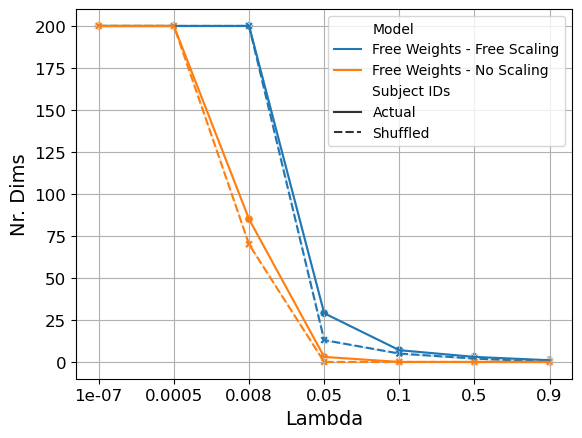

In [59]:
f, ax = plt.subplots(1)

sns.lineplot(data=tbl_plot_long, x="lmbda_cat", y="Nr. Dims", hue="Model", style="Subject IDs", ax=ax)
sns.scatterplot(data=tbl_plot_long, x="lmbda_cat", y="Nr. Dims", hue="Model", style="Subject IDs", legend=False, ax=ax)

ax.set_title(ax.get_title(), fontsize=16)
ax.set_xlabel("Lambda (categorical)", fontsize=14)
ax.set_ylabel("Nr. Dims", fontsize=14)
ax.tick_params(axis='both', labelsize=12)
_ = ax.grid(True)